In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from tensorflow.keras.applications import DenseNet201, MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-04-16 12:16:19.892046: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-16 12:16:21.362413: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744785981.991703 4002348 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744785982.176637 4002348 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744785983.570847 4002348 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

In [3]:
def preprocess_image(img_path, show_steps=False):
    img = cv2.imread(img_path)
    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for visualization
    
    grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Grayscale Conversion
    noise_removed = cv2.GaussianBlur(grayscale, (5,5), 0)  # Noise Removal
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    contrast_enhanced = clahe.apply(noise_removed)  # Contrast Enhancement
    resized = cv2.resize(contrast_enhanced, (224, 224))  # Resizing to 224x224
    processed_img = np.stack((resized,)*3, axis=-1)  # Convert grayscale back to 3 channels
    processed_img = processed_img / 255.0  # Normalize
    
    if show_steps:
        fig, axes = plt.subplots(1, 6, figsize=(18, 5))
        axes[0].imshow(original)
        axes[0].set_title("Original")
        axes[1].imshow(grayscale, cmap='gray')
        axes[1].set_title("Grayscale")
        axes[2].imshow(noise_removed, cmap='gray')
        axes[2].set_title("Noise Removed")
        axes[3].imshow(contrast_enhanced, cmap='gray')
        axes[3].set_title("Contrast Enhanced")
        axes[4].imshow(resized, cmap='gray')
        axes[4].set_title("Resized (224x224)")
        axes[5].imshow(processed_img)
        axes[5].set_title("Final Preprocessed")
        for ax in axes:
            ax.axis("off")
        plt.show()
    
    return processed_img

In [4]:
def load_dataset(dataset_path, categories, show_samples=False):
    X, y = [], []
    sample_shown = False
    for label, category in enumerate(categories):
        folder_path = os.path.join(dataset_path, category)
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            if show_samples and not sample_shown:
                print(f"Category: {category}")
                X.append(preprocess_image(img_path, show_steps=True))
                sample_shown = True
            else:
                X.append(preprocess_image(img_path))
            y.append(label)
    return np.array(X), np.array(y)

In [5]:
def visualize_features(model, images, title):
    feature_extractor = Model(inputs=model.input, outputs=model.layers[-4].output)
    features = feature_extractor.predict(images)

    # Convert feature map to a plottable format
    feature_map = np.mean(features[0], axis=-1)  # Average over channels
    
    plt.figure(figsize=(10, 5))
    plt.imshow(feature_map, cmap='viridis')
    plt.title(title)
    plt.axis('off')
    plt.colorbar()
    plt.show()

In [6]:
def build_model():
    inputs1 = tf.keras.Input(shape=(224, 224, 3), name="input_1")
    inputs2 = tf.keras.Input(shape=(224, 224, 3), name="input_2")
    base_model1 = DenseNet201(weights='imagenet', include_top=False, input_tensor=inputs1)
    base_model2 = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs2)
    
    for layer in base_model1.layers[-50:]:
        layer.trainable = True
    for layer in base_model2.layers[-50:]:
        layer.trainable = True
    
    x1 = GlobalAveragePooling2D()(base_model1.output)
    x2 = GlobalAveragePooling2D()(base_model2.output)
    
    visualize_features(base_model1, np.expand_dims(X[0], axis=0), "Features from DenseNet201")
    visualize_features(base_model2, np.expand_dims(X[0], axis=0), "Features from MobileNetV2")
    
    merged = tf.keras.layers.Concatenate()([x1, x2])
    visualize_features(Model(inputs=[inputs1, inputs2], outputs=merged), [np.expand_dims(X[0], axis=0)]*2, "Features After Fusion")
    
    x = Dense(512, activation='relu')(merged)
    x = Dropout(0.5)(x)
    output = Dense(6, activation='softmax')(x)
    return Model(inputs=[inputs1, inputs2], outputs=output)

In [7]:
dataset_path='dataset-resized/dataset-resized'
categories = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
image_size = (224, 224)

X, y = [], []
for label, category in enumerate(categories):
    folder_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, image_size)
        img = img / 255.0  # Normalize
        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

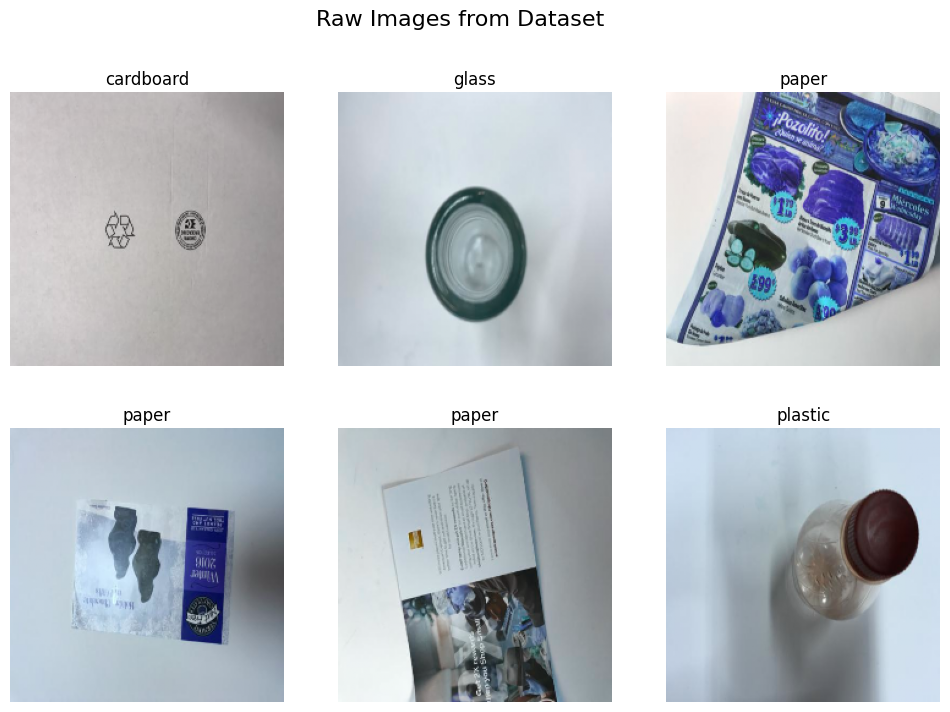

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(X))
    ax.imshow(X[idx])
    ax.set_title(categories[y[idx]])
    ax.axis('off')

plt.suptitle("Raw Images from Dataset", fontsize=16)
plt.show()

Category: cardboard


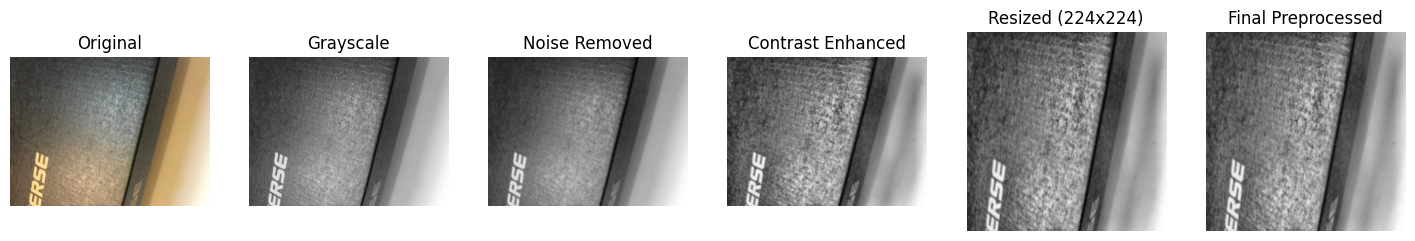

In [9]:
categories = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
dataset_path = "dataset-resized/dataset-resized"
X, y = load_dataset(dataset_path, categories, show_samples=True)

In [10]:
def data_generator(X1, X2, y, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices(((X1, X2), y))
    dataset = dataset.shuffle(len(X1)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
history_list = []

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=10000,
    decay_rate=0.9
)

for train_index, val_index in kf.split(X):
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    train_dataset = data_generator(X_train, X_train, y_train, batch_size=32)
    val_dataset = data_generator(X_val, X_val, y_val, batch_size=32)

2025-04-16 12:18:09.897400: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


/tmp/ipykernel_4002348/604538113.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model2 = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs2)
/SASTRA-NEW-CLUSTER/users/tanusree/miniconda3/envs/tanu/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_1']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


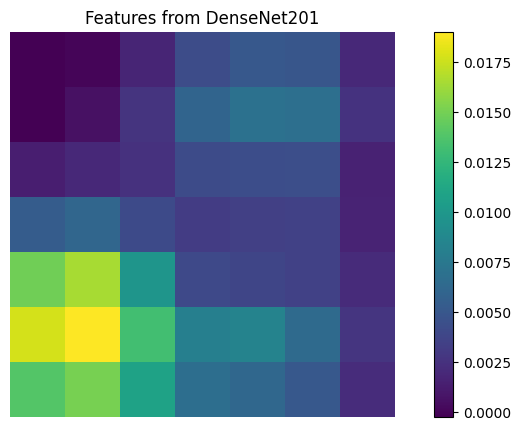

/SASTRA-NEW-CLUSTER/users/tanusree/miniconda3/envs/tanu/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_2']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step


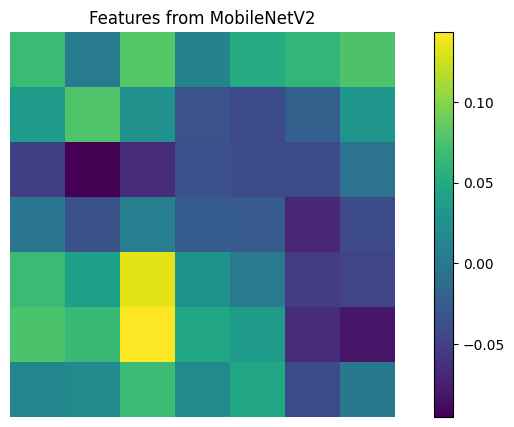

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step


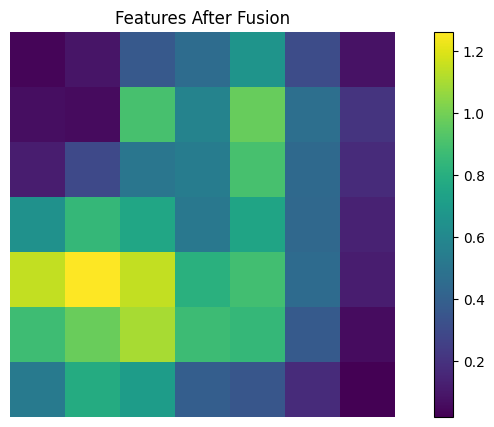

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 270s 3s/step - accuracy: 0.5056 - loss: 1.4244 - val_accuracy: 0.6832 - val_loss: 0.8484
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.9071 - loss: 0.2828 - val_accuracy: 0.7089 - val_loss: 0.7890
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.9752 - loss: 0.1146 - val_accuracy: 0.7267 - val_loss: 0.8113
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.9821 - loss: 0.0540 - val_accuracy: 0.7624 - val_loss: 0.7658
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9905 - loss: 0.0376 - val_accuracy: 0.8277 - val_loss: 0.5718
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.9864 - loss: 0.0409 - val_accuracy: 0.8257 - val_loss: 0.5173
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9692 - loss: 0.1093 - val_accuracy: 0.8119 - val_loss: 0.7362
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9760 - loss: 0.0658 - val_accuracy: 0.7822 - v

In [13]:
model = build_model()
model.compile(optimizer=Adam(learning_rate=lr_schedule), 
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history = model.fit(train_dataset, validation_data=val_dataset, epochs=20)
history_list.append(history)
    
loss, accuracy = model.evaluate(val_dataset)
fold_accuracies.append(accuracy)

print(f"Average Accuracy Across Folds: {np.mean(fold_accuracies) * 100:.2f}%")

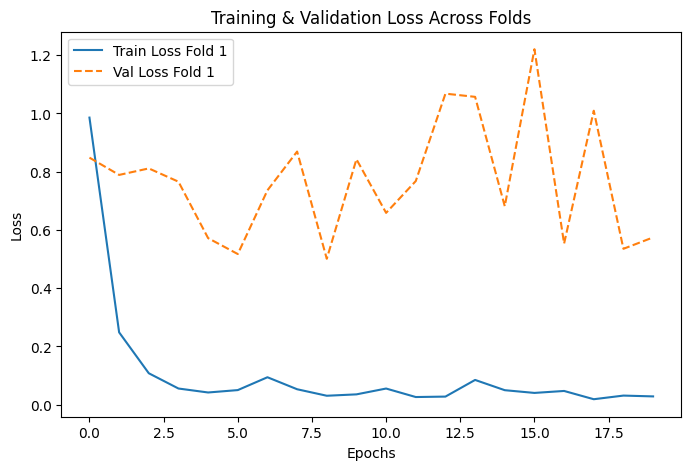

In [14]:
plt.figure(figsize=(8,5))
for i, history in enumerate(history_list):
    plt.plot(history.history['loss'], label=f'Train Loss Fold {i+1}')
    plt.plot(history.history['val_loss'], label=f'Val Loss Fold {i+1}', linestyle='dashed')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss Across Folds")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step


2025-04-16 13:17:32.157101: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Fold Metrics -> Precision: 0.8594, Recall: 0.8535, F1: 0.8531
              precision    recall  f1-score   support

   cardboard       0.93      0.94      0.94        69
       glass       0.94      0.79      0.86       102
       metal       0.79      0.92      0.85        88
       paper       0.91      0.87      0.89       123
     plastic       0.75      0.87      0.81        89
       trash       0.71      0.59      0.65        34

    accuracy                           0.85       505
   macro avg       0.84      0.83      0.83       505
weighted avg       0.86      0.85      0.85       505



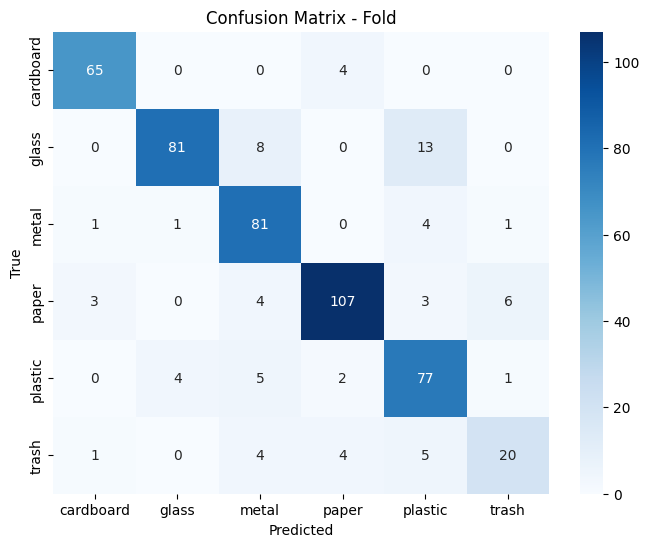

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_val_true = []
y_val_pred = []

for batch in val_dataset:
    (x1, x2), labels = batch
    preds = model.predict([x1, x2])
    y_val_true.extend(labels.numpy())
    y_val_pred.extend(np.argmax(preds, axis=1))

# Metrics
precision = precision_score(y_val_true, y_val_pred, average='weighted')
recall = recall_score(y_val_true, y_val_pred, average='weighted')
f1 = f1_score(y_val_true, y_val_pred, average='weighted')
report = classification_report(y_val_true, y_val_pred, target_names=categories)

print(f"Fold Metrics -> Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
print(report)

# Confusion Matrix
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Fold')
plt.show()


In [16]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([img_array, img_array])
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradient of the class wrt output feature map
    grads = tape.gradient(class_channel, conv_outputs)

    # Mean intensity of gradient for each feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in feature map array by the importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [17]:
def show_gradcam(img, heatmap, alpha=0.4):
    import cv2
    img = np.uint8(255 * img)  # Original image scaled back up
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title("Grad-CAM")
    plt.show()

/SASTRA-NEW-CLUSTER/users/tanusree/miniconda3/envs/tanu/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_1', 'input_2']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))', 'Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


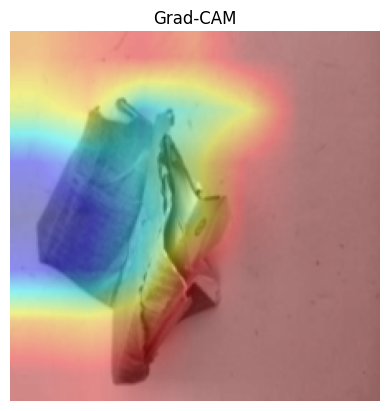

In [18]:
# Choose a test image (shape must be [1, 224, 224, 3])
test_img = np.expand_dims(X[100], axis=0)

# You must know the name of the last conv layer
# For DenseNet201 usually: "conv5_block32_concat"
# For MobileNetV2: "Conv_1"

heatmap = make_gradcam_heatmap(test_img, model, last_conv_layer_name="Conv_1")  # Example
show_gradcam(X[100], heatmap)

In [26]:
!pip install tf-explain opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 5.6 MB/s eta 0:00:0000:0100:01m


In [38]:
mobilenet_cam_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,916,934 (11.13 MB)

 Trainable params: 658,950 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [40]:
def build_mobilenet_cam_model_for_gradcam():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    # Grab the last conv layer from within the base model
    last_conv_layer = base_model.get_layer("Conv_1").output  # Shape: (None, 7, 7, 1280)

    x = GlobalAveragePooling2D()(last_conv_layer)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(6, activation='softmax')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    return model


/SASTRA-NEW-CLUSTER/users/tanusree/miniconda3/envs/tanu/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1025']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


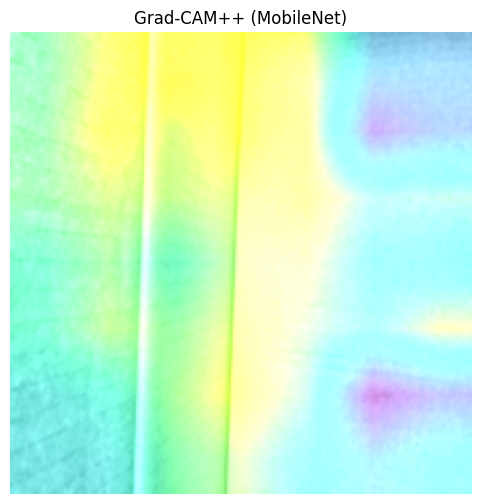

In [41]:
mobilenet_cam_model = build_mobilenet_cam_model_for_gradcam()
run_gradcam_tf_explain(
    model=mobilenet_cam_model,
    img=img,
    class_index=true_label,
    target_layer="Conv_1"  # works now because it's directly accessible
)

In [42]:
def build_densenet_cam_model_for_gradcam():
    base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    # Last conv layer in DenseNet201
    last_conv_layer = base_model.get_layer("conv5_block32_concat").output  # 1920 filters

    x = GlobalAveragePooling2D()(last_conv_layer)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(6, activation='softmax')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    return model

In [44]:
from tf_explain.core.grad_cam import GradCAM
import os
import cv2

def batch_gradcam_images(model, X_data, y_data, layer_name, output_dir="gradcam_outputs", sample_count=10):
    """
    Generate Grad-CAM++ heatmaps for a batch of images and save them.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    for i in range(sample_count):
        img = X_data[i]
        label = y_data[i]
        
        try:
            explainer = GradCAM()
            img_batch = np.expand_dims(img, axis=0)
            heatmap = explainer.explain(
                validation_data=(img_batch, None),
                model=model,
                class_index=label,
                layer_name=layer_name
            )

            # Save CAM image
            out_path = os.path.join(output_dir, f"class_{label}_img_{i}.png")
            cv2.imwrite(out_path, cv2.cvtColor(heatmap, cv2.COLOR_RGB2BGR))
            print(f"[✓] Saved Grad-CAM for image {i} → {out_path}")
        
        except Exception as e:
            print(f"[!] Failed on image {i}: {e}")

In [45]:
densenet_cam_model = build_densenet_cam_model_for_gradcam()

# Generate 10 sample CAMs
batch_gradcam_images(
    model=densenet_cam_model,
    X_data=X,
    y_data=y,
    layer_name="conv5_block32_concat",  # last conv layer of DenseNet201
    output_dir="gradcam_densenet201",
    sample_count=10
)

/SASTRA-NEW-CLUSTER/users/tanusree/miniconda3/envs/tanu/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1894']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


[✓] Saved Grad-CAM for image 0 → gradcam_densenet201/class_0_img_0.png
[✓] Saved Grad-CAM for image 1 → gradcam_densenet201/class_0_img_1.png
[✓] Saved Grad-CAM for image 2 → gradcam_densenet201/class_0_img_2.png
[✓] Saved Grad-CAM for image 3 → gradcam_densenet201/class_0_img_3.png
[✓] Saved Grad-CAM for image 4 → gradcam_densenet201/class_0_img_4.png
[✓] Saved Grad-CAM for image 5 → gradcam_densenet201/class_0_img_5.png
[✓] Saved Grad-CAM for image 6 → gradcam_densenet201/class_0_img_6.png
[✓] Saved Grad-CAM for image 7 → gradcam_densenet201/class_0_img_7.png
[✓] Saved Grad-CAM for image 8 → gradcam_densenet201/class_0_img_8.png
[✓] Saved Grad-CAM for image 9 → gradcam_densenet201/class_0_img_9.png


In [46]:
import matplotlib.pyplot as plt
import cv2

def show_gradcam_image(image_path, title="Grad-CAM"):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(title)
    plt.show()

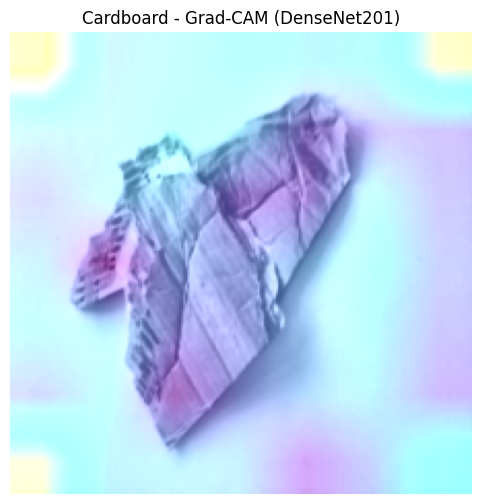

In [49]:
# Change index or use os.listdir to browse
show_gradcam_image("gradcam_densenet201/class_0_img_6.png", title="Cardboard - Grad-CAM (DenseNet201)")

In [50]:
model.save('rwcnet.h5')